# Energy Time Series Forecasting


### 1. Read the dataset

In [1]:
import pandas as pd
import numpy as np

In [2]:
#Load the dataset
data = pd.read_csv('energydata_complete.csv')
data.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,11/01/2016 17:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.60,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,11/01/2016 17:10,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.48,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,11/01/2016 17:20,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.37,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,11/01/2016 17:30,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.25,733.8,92.0,6.000000,51.500000,5.0,45.410390,45.410390
4,11/01/2016 17:40,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.13,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [3]:
# Display the distribution of the dataset
data.describe()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,39.026904,...,19.485828,41.552401,7.412580,755.522602,79.750418,4.039752,38.330834,3.760995,24.988033,24.988033
std,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,4.341321,...,2.014712,4.151497,5.318464,7.399441,14.901088,2.451221,11.794719,4.195248,14.496634,14.496634
min,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,27.660000,...,14.890000,29.166667,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.005322
25%,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,35.530000,...,18.000000,38.500000,3.670000,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,12.497889
50%,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,38.400000,...,19.390000,40.900000,6.920000,756.100000,83.666667,3.666667,40.000000,3.430000,24.897653,24.897653
75%,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,42.156667,...,20.600000,44.338095,10.400000,760.933333,91.666667,5.500000,40.000000,6.570000,37.583769,37.583769
max,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,51.090000,...,24.500000,53.326667,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,49.996530


### 2. Analyse and visualise the data

According to (Candanedo, L.M.) provided, this dataset is the energy use of appliances, including measurements of temperature, humidity and weather(press, wind speed and visibility).  

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  object 
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  float64
 19  T9  

In [5]:
# Chech if there is any missing values to determine whether Mice is needed
data.isnull().sum()

date           0
Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
dtype: int64

The result indicates that the dateset has got 19735 records of the appliances of the house, and there is no missing values. But the 'date' is non-numeric, so this column of data need to be transferred to another format that could represent the time of day, date and weekends, which could help to analysis time series.  
  
Besides 'date', the rest 27 variables are int64 or float64, including two variables named 'r1', 'r2' seems represent noise or random of the dataset.

The dataset recorded energy use of 2016 from January to May. As this task is aiming at predict time series of Appliances, A new dataset is formed to contain only 'Date' and 'Appliances'.

In [6]:
# Transfer 'date' data into numeric format
data['date'] = pd.to_datetime(data['date'], dayfirst=True)

# Create a new dataset to contain only date and appliances.
new_data = data.copy()
new_data = new_data[['date', 'Appliances']]
new_data.head()

,date,Appliances
0,2016-01-11 17:00:00,60
1,2016-01-11 17:10:00,60
2,2016-01-11 17:20:00,50
3,2016-01-11 17:30:00,50
4,2016-01-11 17:40:00,60


In [7]:
import matplotlib.pyplot as plt 
import seaborn as sns

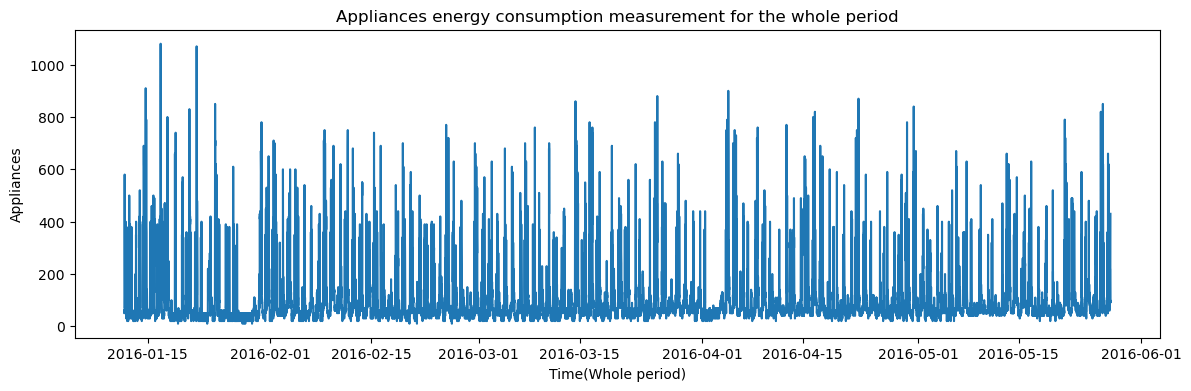

In [8]:
# Appliances energy consumption measurement for the whole period
plt.subplots(figsize=(14,4))
plt.plot(new_data['date'],new_data['Appliances'])
plt.xlabel('Time(Whole period)')
plt.ylabel('Appliances')
plt.title('Appliances energy consumption measurement for the whole period')
plt.show()

Set 'date' column into 'month' (using 1 to represent January), 'hour_minute'(using 17.5 to represent 17:30:00) and 'weekday'(using 1 to represent Monday).

In [9]:
# Split the 'date' into day of week, time of day, and weekdays
new_data['month_day'] = new_data['date'].dt.month + round(new_data['date'].dt.day / 30,2)
new_data['hour_minute'] = new_data['date'].dt.hour + round(new_data['date'].dt.minute / 60,2)  
new_data['weekday'] = new_data['date'].dt.weekday 

# Set 'date' as index
new_data.set_index('date', inplace = True)

# Display the first few rows to verify the new features
new_data.head()

,Appliances,month_day,hour_minute,weekday
date,,,,
2016-01-11 17:00:00,60,1.37,17.00,0
2016-01-11 17:10:00,60,1.37,17.17,0
2016-01-11 17:20:00,50,1.37,17.33,0
2016-01-11 17:30:00,50,1.37,17.50,0
2016-01-11 17:40:00,60,1.37,17.67,0


In [10]:
# Calculate the total energy per hour for the whole period
per_hour = new_data.groupby(by='hour_minute', as_index=False)['Appliances'].sum()
per_hour.T

,0,1,2,3,4,5,6,7,8,9,...,134,135,136,137,138,139,140,141,142,143
hour_minute,0.0,0.17,0.33,0.5,0.67,0.83,1.0,1.17,1.33,1.5,...,22.33,22.5,22.67,22.83,23.0,23.17,23.33,23.5,23.67,23.83
Appliances,7380.0,7450.00,7140.00,6940.0,7240.00,7240.00,7170.0,7210.00,6920.00,6920.0,...,9650.00,9150.0,8210.00,7920.00,7870.0,7860.00,8030.00,8080.0,7550.00,7450.00


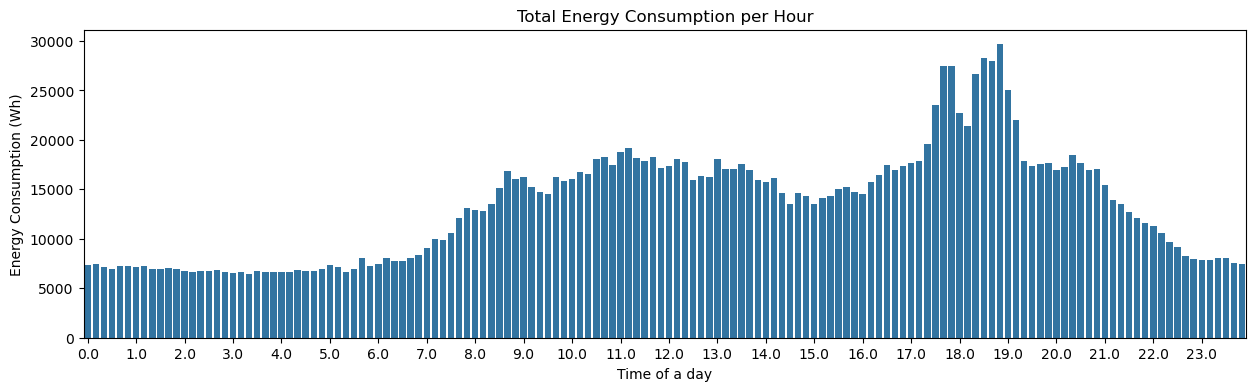

In [11]:
plt.subplots(figsize=(15,4))
sns.barplot(x=per_hour['hour_minute'], y=per_hour['Appliances'])
plt.xticks(range(0, 144, 6))# Arrange the X-axis to per hour
plt.xlabel('Time of a day')
plt.ylabel('Energy Consumption (Wh)')
plt.title('Total Energy Consumption per Hour')
plt.show()

The barplot indicates that appliances is highest between 17:30 and 19:00 for the whole period. There is some basic use of energy at night at a low level.

In [12]:
# Calculate the average energy use of every weekday for the whole period
per_weekday = new_data.groupby(by='weekday', as_index=False)['Appliances'].mean()
per_weekday.T

,0,1,2,3,4,5,6
weekday,0.000000,1.000,2.000000,3.000000,4.000000,5.000000,6.000000
Appliances,111.450684,87.125,89.930556,90.434028,104.622144,106.246345,94.915936


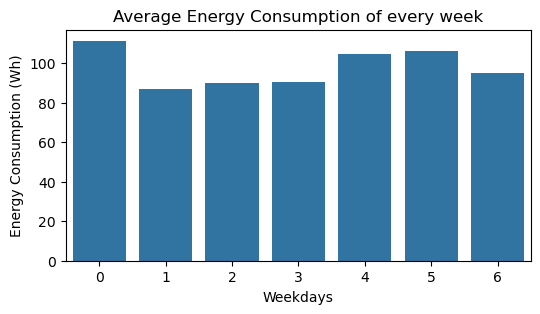

In [13]:
plt.subplots(figsize=(6,3))
sns.barplot(x=per_weekday['weekday'], y=per_weekday['Appliances'])
plt.xlabel('Weekdays')
plt.ylabel('Energy Consumption (Wh)')
plt.title('Average Energy Consumption of every week')
plt.show()

Text(0, 0.5, 'Energy Consumption (Wh)')

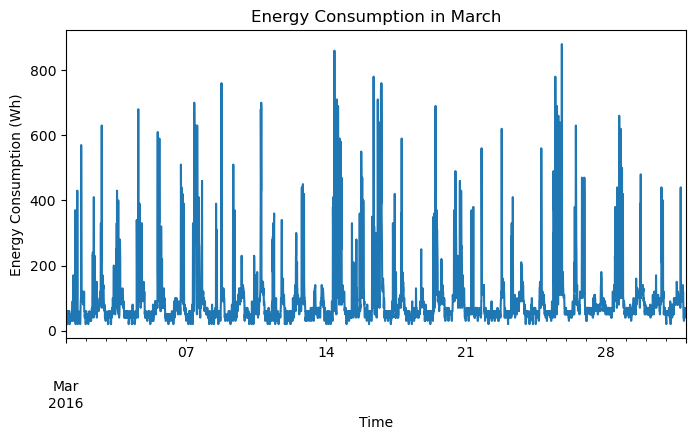

In [14]:
new_data.Appliances['2016-03-01':'2016-03-31'].plot(figsize=(8,4))
plt.title('Energy Consumption in March')
plt.xlabel('Time')
plt.ylabel('Energy Consumption (Wh)')

There is no strong evidence that Appliances is related to different days of a week. But plotting of energy use in a month, there shows obvious seasonality.

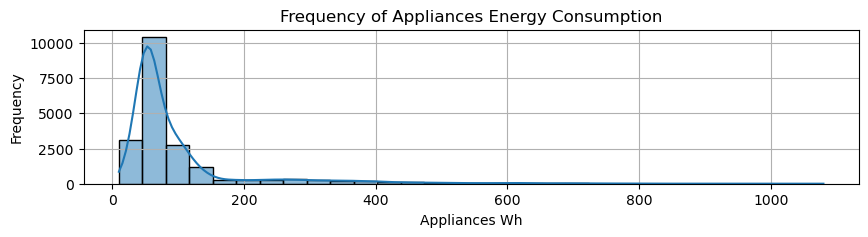

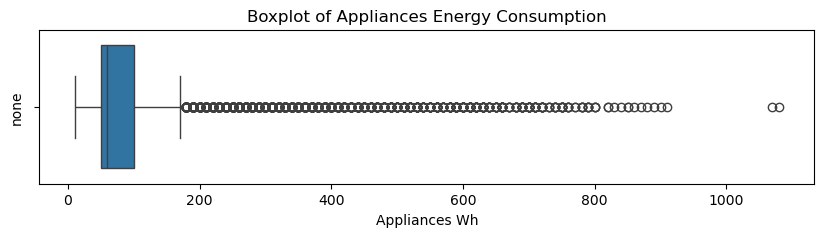

In [15]:
# Plot the frequency of the 'Appliances' energy consumption values
plt.figure(figsize=(10, 2))
sns.histplot(new_data['Appliances'], bins=30, kde=True)
plt.title('Frequency of Appliances Energy Consumption')
plt.xlabel('Appliances Wh')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 2))  
sns.boxplot(x=new_data['Appliances'])
plt.xlabel('Appliances Wh')
plt.title('Boxplot of Appliances Energy Consumption')
plt.ylabel('none')
plt.show()

The histogram of Aplliances is right-skewed, which has a long tail. It indicates that most of the period appliances remains at a low level, but occasionally the energy comsuption is pretty high.

The baxplot confirms that most range of appliance is between 0 to 200, and beyond that are outliers.

In [16]:
from statsmodels.tsa.stattools import adfuller
from numpy import log
import statsmodels.api as sm
import numpy as np, pandas as pd
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

Time series data is composed of three compenents: trend seasonality and noise (P B, G., & Mathew, J.A.).  Method 'tsa.seasonal_decompose of statsmodels' (statsmodels.tsa.seasonal.seasonal_decompose)  is used to find out these three features.

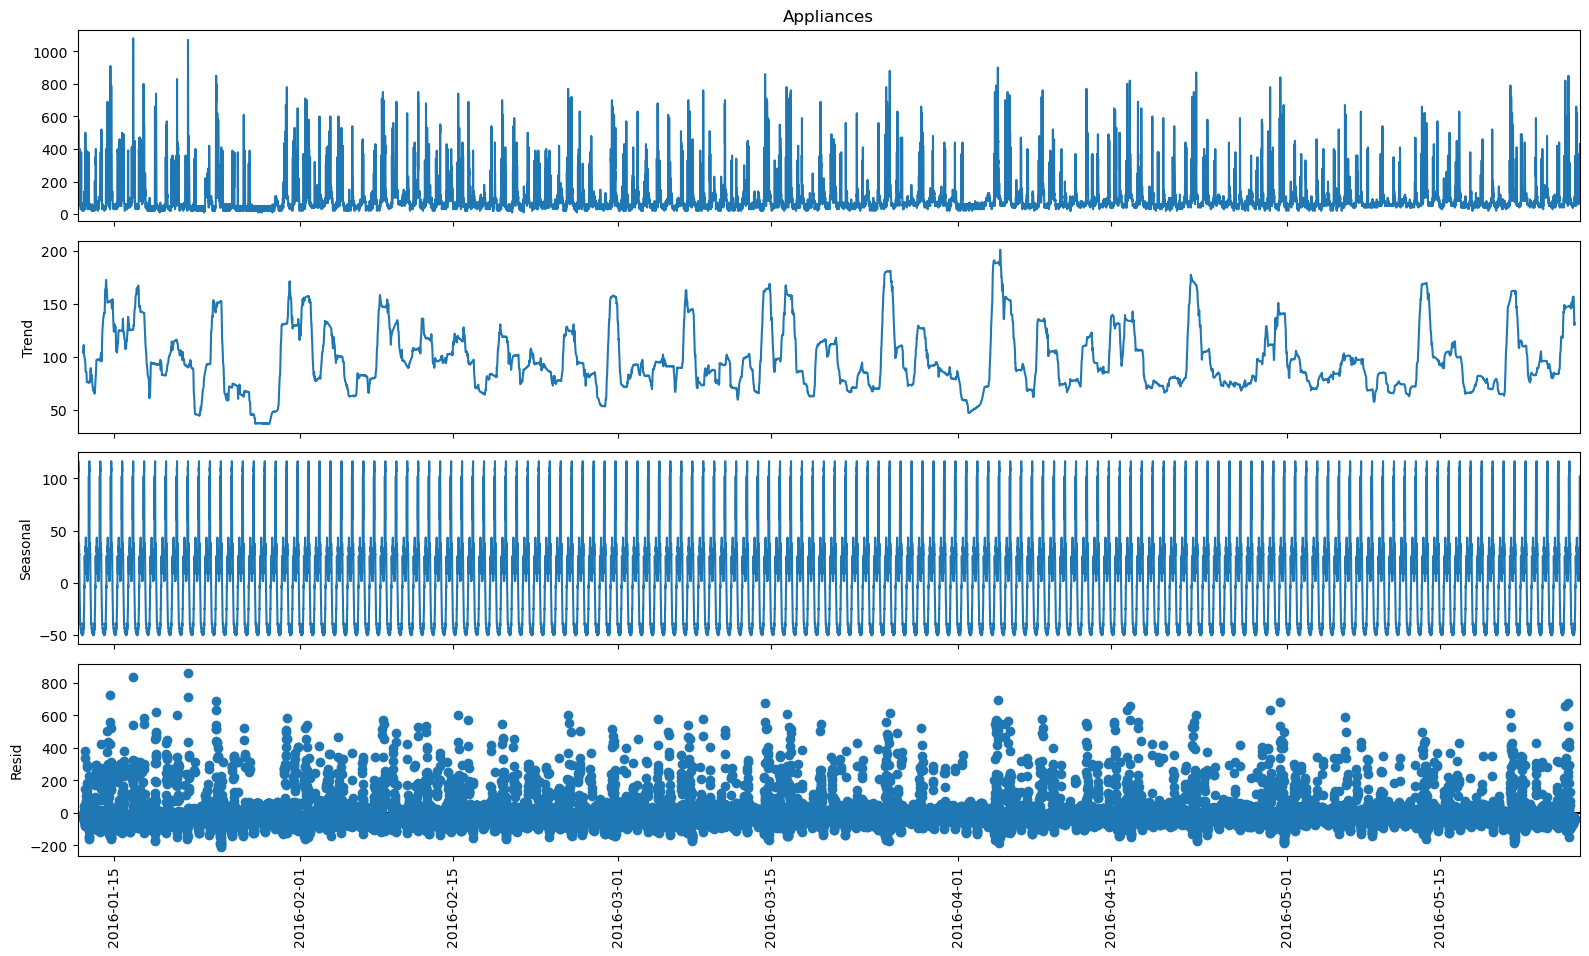

In [17]:
plt.rcParams['figure.figsize'] = 16, 9
decomposed_Appliances_volume = sm.tsa.seasonal_decompose(new_data['Appliances'],model='additive',period=144) # The frequncy is for everyday
figure = decomposed_Appliances_volume.plot()
plt.xticks(rotation=90) 
plt.show()

From the original model there exists high and low data and there seems to be a trend.  
  
The trend graph shows a slightly periodic change and for long term it does not graduallly increase or decrease.  
  
The seasonality graph shows a significant periodic and repeat pattern, which might related to some cyclical energy comsuption. And this coincides with the daily energy use pattern that there is a period between 17:00 to 19:00 as a high peak use of energy.  
  
However, Resid part, which represents noise, indicates that there are something else that could be the component of this time series, such as weekday or not, holidays, etc.  
  
According to the result of the decompsition, there exists strong seasonality of the dataset. In this case, SARIMA might perform better than just using ARIMA, so does LSTM. After trying to use grid search to find the best parameters, I found it is very time consuming and the result is not very well when I simply just use basic random seasonal order of (1,0,1,1).  
  
So, in this project, I will just use ARIMA and LSTM to find the the prediction of Appliances to Date.

### 3. Pre-process the data

In [18]:
# checking for null values
new_data.isnull().sum()

Appliances     0
month_day      0
hour_minute    0
weekday        0
dtype: int64

There is no missing value in the dataset.  
  
In the data visualization part, the 'date' data is non-numeric and it has been converted into datime, and splited into day, time and weekdays.  

After visualizing the features of dataset, the splited date elements month_day, hour_minute, weekdays is not used in the ARIMA and LSTM model. So drop these data and use just Date and Appliances to predict the time series.

In [19]:
data_pro = new_data.copy()
data_pro.drop(['month_day','hour_minute','weekday'],axis = 1,inplace = True)
data_pro

,Appliances
date,
2016-01-11 17:00:00,60
2016-01-11 17:10:00,60
2016-01-11 17:20:00,50
2016-01-11 17:30:00,50
2016-01-11 17:40:00,60
...,...
2016-05-27 17:20:00,100
2016-05-27 17:30:00,90
2016-05-27 17:40:00,270


#### ARIMA data pre-processing

In [20]:
# Split the dataset into train(80%) and test(20%) for ARIMA
train_size = int(len(new_data)*0.8)
train_data = data_pro[ :train_size]
test_data = data_pro[train_size:]

In [21]:
train_data = np.array(train_data)
train_data

array([[ 60],
       [ 60],
       [ 50],
       ...,
       [ 50],
       [ 70],
       [300]], dtype=int64)

In [22]:
test_data = np.array(test_data)
test_data

array([[370],
       [590],
       [320],
       ...,
       [270],
       [420],
       [430]], dtype=int64)

#### LSTM data pre-processing

In [23]:
from sklearn.preprocessing import MinMaxScaler

In [24]:
scaler = MinMaxScaler(feature_range = (0, 1))
data_scaled = scaler.fit_transform(data_pro)

In [25]:
data_scaled

array([[0.04672897],
       [0.04672897],
       [0.03738318],
       ...,
       [0.24299065],
       [0.38317757],
       [0.39252336]])

In [26]:
train_lstm = data_scaled[ :train_size]
test_lstm = data_scaled[train_size:]

In [27]:
print(f'The size of train and test of LSTM is {np.shape(train_lstm)} and {np.shape(test_lstm)}')

The size of train and test of LSTM is (15788, 1) and (3947, 1)


In [28]:
d = 144 # Change this parameter to 144, to use formal day data to predict next day, as the dataset has a seasonality of one day.
epochs = 20
batch_size = 32

In [29]:
features_set = []
labels = []
for i in range(d, train_lstm.shape[0]):
    features_set.append(train_lstm[i-d:i,0])
    labels.append(train_lstm[i,0])

In [30]:
x_train, y_train = np.array(features_set), np.array(labels)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

In [31]:
print(f'The size of x_train and y_train of LSTM is {x_train.shape} and {y_train.shape}')

The size of x_train and y_train of LSTM is (15644, 144, 1) and (15644,)


In [32]:
test_inputs = data_scaled[len(data_scaled) - len(test_data) - d:]
#test_inputs = test_inputs.reshape(-1,1)

test_features = []
for i in range(d, test_inputs.shape[0]):
    test_features.append(test_inputs[i-d:i,0])
    
    
x_test = np.array(test_features)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1)) 

In [33]:
print(f'The size of x_test of LSTM is {x_test.shape}')

The size of x_test of LSTM is (3947, 144, 1)


### 4. Implement, train and test prediction models[5]

### ARIMA

The following code is referenced to workshop of week 6.

In [34]:
# Find the differential parameter d.
result = adfuller(train_data)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

ADF Statistic: -19.010131
p-value: 0.000000


p-value = 0.0000 indicats that the time series is stationary and there is no need to proceed differncing, parameter d can be chosen to 0.

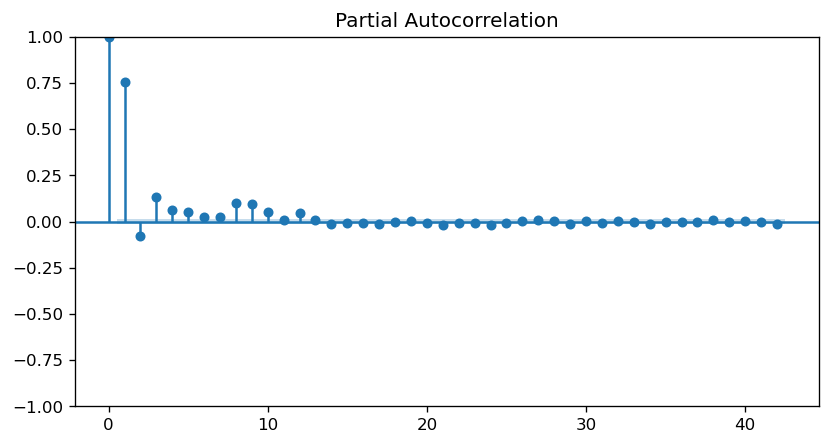

In [35]:
# Find the AR parameter p
plt.rcParams.update({'figure.figsize':(8,4), 'figure.dpi':120})
plot_pacf(train_data)
plt.show()

Partial Autocorrelation (PACF) is a correlation between given lag and the series after excluding intermediate lags. In this chart lag 7 is below the significance level,so choose p=7.

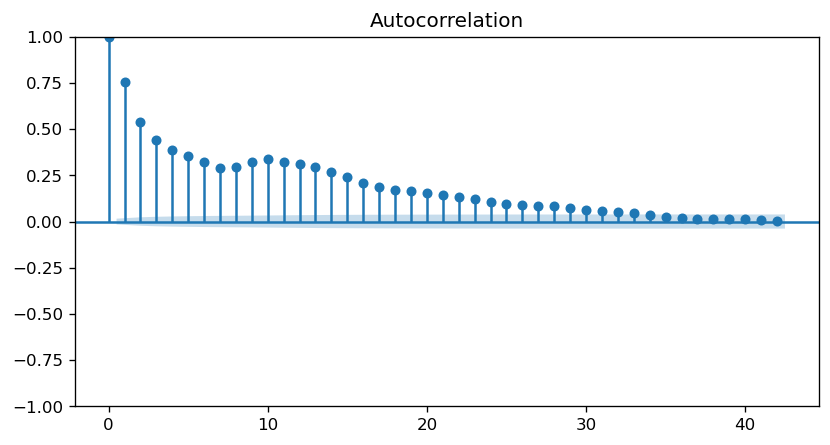

In [36]:
# Set the matplotlib rcParams for figure size and dpi
plt.rcParams.update({'figure.figsize':(8,4), 'figure.dpi':120})
plot_acf(train_data)
plt.show()


q is the Moving Average (MA) part (moving average to remove error term).  
Look at the Autocorrelation function (ACF), 33 lags are over significance, q = 33.

However, if the autocorrelations are positive for many number of lags (10 or more), then the series needs higher d. (lecture 6).   
In this case, plot what ACF and FACF would be.

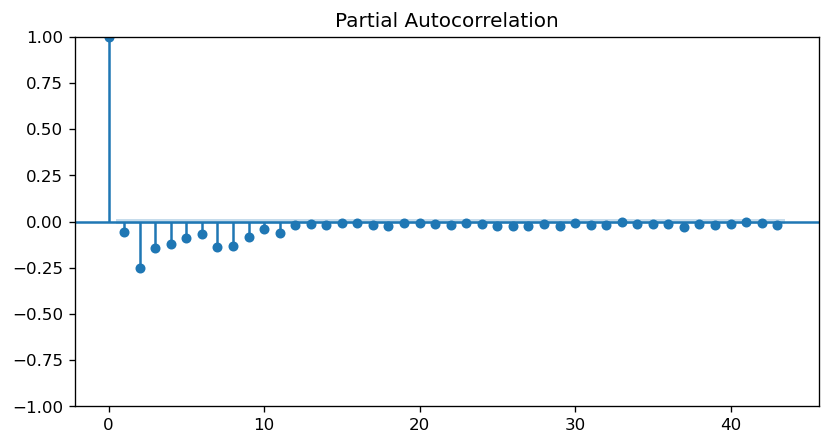

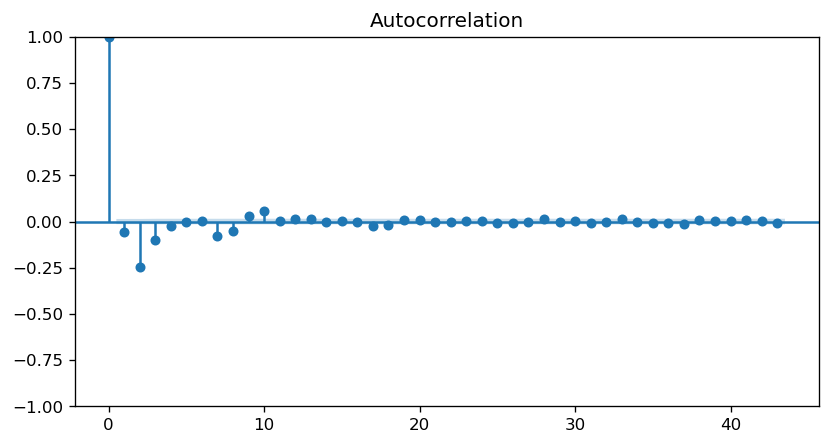

In [37]:
# PACF plot of 1st differenced series
plot_pacf(new_data['Appliances'].diff().dropna())


# ACF plot of 1st differenced series
plot_acf(new_data['Appliances'].diff().dropna())

plt.show()

After first differenting, lag get negative autocorrelation, which means it is over-differentiated. So d should remain 0.

I have tried order=(7,0,33) and order= (1,0,1) for ARIMA model, the difference of the RSME, MAE and MAPE between these two are not too much, but order=(7,0,33) case performances well in capturing vibration-like feature. Considering order=(7,0,33) is very time consuming. So in this assignment, I will just use order= (1,0,1) for ARIMA model.

In [38]:
from statsmodels.tsa.arima.model import ARIMA

# Fit the ARIMA model
arima_model = ARIMA(train_data, order=(1,0,1))
arima_result = arima_model.fit()



In [39]:
# Print out the summary
print(arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                15788
Model:                 ARIMA(1, 0, 1)   Log Likelihood              -89125.804
Date:                Sun, 17 Mar 2024   AIC                         178259.609
Time:                        16:19:39   BIC                         178290.277
Sample:                             0   HQIC                        178269.758
                              - 15788                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         98.0245      3.886     25.226      0.000      90.408     105.641
ar.L1          0.6948      0.005    132.399      0.000       0.685       0.705
ma.L1          0.1445      0.005     26.470      0.0

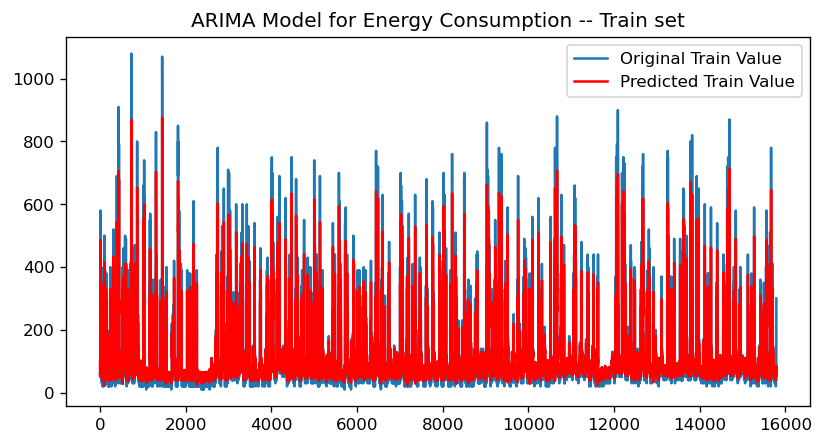

In [40]:
plt.figure(figsize=(8, 4))
plt.plot(train_data, label="Original Train Value")
plt.plot(arima_result.fittedvalues, color='red', label="Predicted Train Value")
plt.title("ARIMA Model for Energy Consumption -- Train set")
plt.legend()
plt.show()

The graph indicates that the ARIMA model has capture most of the features of the dataset, and performed well generally.   
However, the peak energy use prediction is mostly lower than the actual value, which means the model could be still adjusted.

In [41]:
arima_test = arima_result.forecast(steps=len(test_data))
arima_test

array([270.13723909, 217.61011781, 181.11375532, ...,  98.02445847,
        98.02445847,  98.02445847])

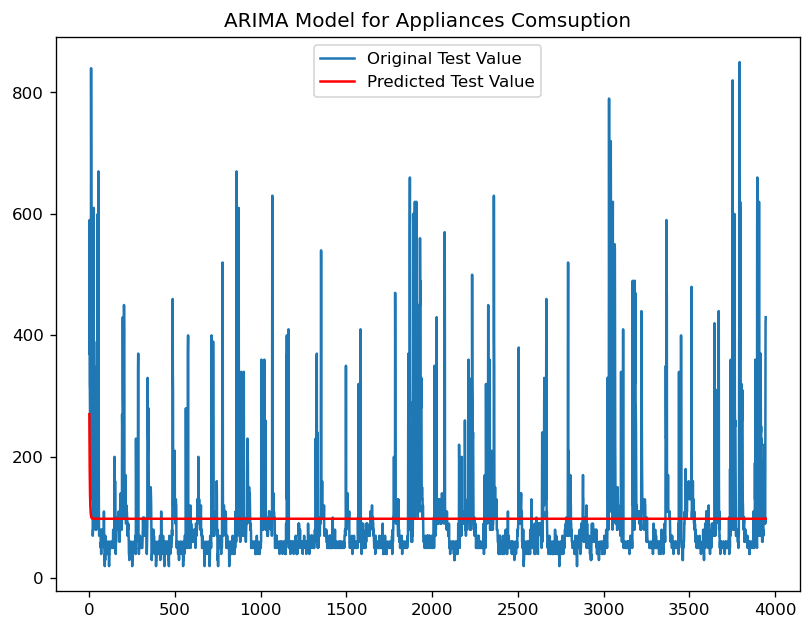

In [42]:
plt.figure(figsize=(8, 6))
plt.plot(test_data, label="Original Test Value")
plt.plot(arima_test, color='red', label="Predicted Test Value")
plt.title("ARIMA Model for Appliances Comsuption")
plt.legend()
plt.show()

By contrasting the original test dataset values and predicted test values from ARIMA, it is obvious that prediction line appears quite flat and it is nearly a line. They position near the lower boundary of the high level of original data.  
  
The model's prediction didn't capture the variable values and seasonality feature of energy use. And predicted enery use is lower than actual ones.  
  
This might due to the use of ARIMA, the model that pickes out seasonality and focus on the trend of data. Simply changing parameters of ARIMA can't make the model perform well. Since by decompsition, there exists a period rythm of Appliances, so in this case SARIMA, which add seasonality into the model might be more suitable for predicting the energy comsumption of the house.
  

Use RMSE, MAE, MAPE of the model to find out if the performance is good. （Mohapatra, Sunil Kumar et al）

In [43]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
print("ARIMA RMSE:", np.sqrt(mean_squared_error(test_data,arima_test)))
print("ARIMA MAE:", mean_absolute_error(test_data,arima_test))
print("ARIMA MAPE:",np.mean(np.abs((test_data - arima_test) / arima_test)) * 100)


ARIMA RMSE: 90.69281340497756
ARIMA MAE: 52.54229910441363
ARIMA MAPE: 53.75982716248657


### LSTM 

The following code is referenced to workshop of week 6.

In [44]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM, SimpleRNN
from tensorflow.keras.layers import Dropout
    
from tensorflow.keras.optimizers import Adam   

In [45]:
model_lstm = Sequential()
model_lstm.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1],1)))
model_lstm.add(Dropout(0.2))
model_lstm.add(LSTM(units=50, return_sequences=True))
model_lstm.add(Dropout(0.2))

model_lstm.add(LSTM(units=50, return_sequences=True))
model_lstm.add(Dropout(0.2))

model_lstm.add(LSTM(units=50))
model_lstm.add(Dropout(0.2))
model_lstm.add(Dense(units = 1))

model_lstm.compile(optimizer = Adam(), loss = 'mean_squared_error')

In [46]:
model_lstm.fit(x_train, y_train, epochs = 20, batch_size = 32)

Epoch 1/20
489/489 [==============================] - 50s 76ms/step - loss: 0.0077
Epoch 2/20
489/489 [==============================] - 37s 75ms/step - loss: 0.0057
Epoch 3/20
489/489 [==============================] - 36s 73ms/step - loss: 0.0043
Epoch 4/20
489/489 [==============================] - 38s 77ms/step - loss: 0.0042
Epoch 5/20
489/489 [==============================] - 37s 75ms/step - loss: 0.0041
Epoch 6/20
489/489 [==============================] - 37s 76ms/step - loss: 0.0042
Epoch 7/20
489/489 [==============================] - 37s 76ms/step - loss: 0.0040
Epoch 8/20
489/489 [==============================] - 37s 75ms/step - loss: 0.0041
Epoch 9/20
489/489 [==============================] - 38s 78ms/step - loss: 0.0040
Epoch 10/20
489/489 [==============================] - 38s 77ms/step - loss: 0.0041
Epoch 11/20
489/489 [==============================] - 37s 77ms/step - loss: 0.0041
Epoch 12/20
489/489 [==============================] - 37s 76ms/step - loss: 0.0041
E

In [47]:
# Use the model to predict by train and test set
y_train_lstm = model_lstm.predict(x_train)
y_pred_lstm = model_lstm.predict(x_test)


124/124 [==============================] - 4s 34ms/step


In [48]:
# Scale all the dataset back into original scale.
y_train_true = scaler.inverse_transform(train_lstm)
y_test_true = scaler.inverse_transform(test_lstm)

y_train_lstm = scaler.inverse_transform(y_train_lstm)
y_pred_lstm = scaler.inverse_transform(y_pred_lstm)

In [49]:
len(y_pred_lstm)

3947

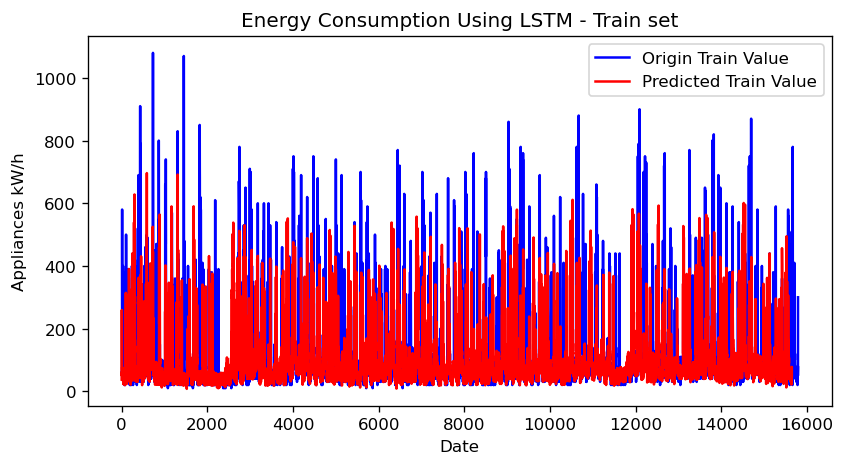

In [50]:
plt.figure(figsize=(8,4))
plt.plot(y_train_true, color='blue', label='Origin Train Value')
plt.plot(y_train_lstm , color='red', label='Predicted Train Value')
plt.title('Energy Consumption Using LSTM - Train set')
plt.xlabel('Date')
plt.ylabel('Appliances kW/h')
plt.legend()
plt.show()

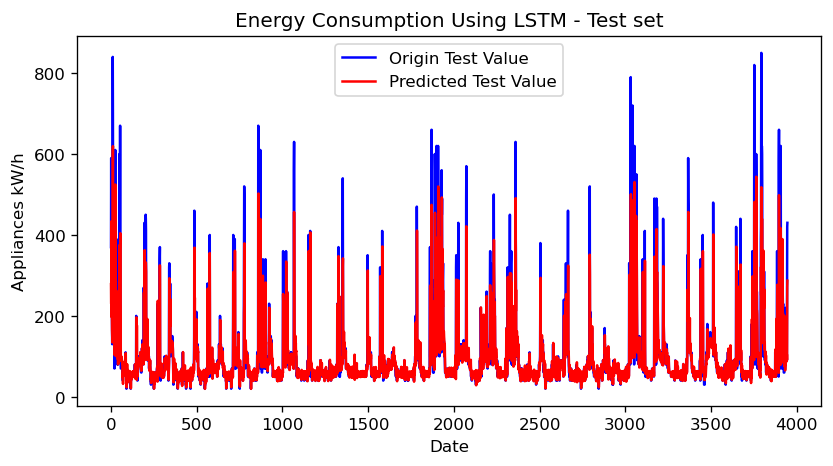

In [51]:
plt.figure(figsize=(8,4))
plt.plot(y_test_true, color='blue', label='Origin Test Value')
plt.plot(y_pred_lstm , color='red', label='Predicted Test Value')
plt.title('Energy Consumption Using LSTM - Test set')
plt.xlabel('Date')
plt.ylabel('Appliances kW/h')
plt.legend()
plt.show()

The LSTM model not only captures the trend of the data but also has predict the seasonality of the data. It shows the peak use of energy , but it is lower than the origin energy use.  
  
LSTM performs far more better than ARIMA since ARIMA cleaned out the seasonality of data, while LSTM could catch this feature especially when there is a period pattern of data.

In [52]:
print("LSTM RMSE:", np.sqrt(mean_squared_error(y_test_true,y_pred_lstm)))
print("LSTM MAE:", mean_absolute_error(y_test_true,y_pred_lstm))
print("LSTM MAPE:",np.mean(np.abs((y_test_true - y_pred_lstm) / y_test_true)) * 100)

LSTM RMSE: 59.36524510780117
LSTM MAE: 25.69617575236384
LSTM MAPE: 22.39751645547488


### 5. Compare the results from all candidate models, choose the best model, justify your choice and discuss the results


Compare with the results you have obtained in Assignment 1a.

|Model Name| LM  | RF |  GBM  |  ARIMA  |  LSTM  |
|:---:|:---:|:---:|:---:|:---:|:---:|
|  RMSE | 92.50 |68.51 | 71.71  | 90.69 | 60.26 |
|  MAE |52.89| 33.02 |36.01| 52.54 | 32.37 |
|  MAPE | /  | / |  /  | 53.76 | 34.09 |

  




The LSTM model results the lowest RMSE, which indicates that using LSTM model made it got the prediction of smallest average error among all the five models. And it got the lowest MAE, which means the smallest average absolute error.
The Random Forest model also performs well, with nearly RMSE and MAE of LSTM.  
  
Compared to other models, ARIMA and Linear Model have the highest RMSE and MAE values, indicating they didn't capture the complexity of the data. This might due to these two methods aims more on linear or trend prediction, while the energy use in this case is more fluctuate and has a strong seasonality.
  
The Gradient Boosting Machine model got the results between the LSTM and ARIMA models.
  
  


In my assignment 1a, MAPE is not calculated, so the comparison of MAPE is just between ARIMA and LSTM.  
  

The LSTM's MAPE is lower than ARIMA's, indicating LSTM's predition is more accurate than ARIMA as LSTM has lower percentage of the error.  
  
In summary, the LSTM model outperforms the other models according to these five metrics, which makes it the perfect model for the energy consumption prediction among those models.   
However, further more optimal methods could be used to LSTM model, or other selection to improve interpretability and computational efficiency.

### 6. Summary

After completing all the steps, I managed how to use ARIMA and LSTM to predict time series with more deep understanding. 
  
This job doesn't include so many features that may affect the energy use prediction. So besides 'date' and 'Appliances', the other data could discard. I found that prediction could not only be made by considering tremendous influences but also be made by just exploring time series. The result of five models also proves that in this energy consumption case, due to the pattern by time, using time series to predict got the better accuracy.  
  
As I have pointed out in the pre-processing section, SARIMA might be more suitable if we want to use this kind of method because SARIMA doesn't pick out the seasonality. So, further expirement could be done in the future to find out how to choose parameters for SARIMA and whether or not it will give a better performance than ARIMA, even LSTM.  
  
Even though LSTM got a beautiful result comparing to others, there still exists parameters, layers, drop or not and other propects that could be improved.  
  
In conclusion, this project prepared me with data mining experience and opened my mind of how to deal with different data type and how to use proper method or model to get the result and connection I want.